In [341]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import math
import random as rand
from scipy.spatial import Voronoi, voronoi_plot_2d

In [342]:
# Generates data from k-Means
# Zach
def generate_dataset(no_of_clusters: int, no_of_points_per_cluster: int):

    random_data = np.random.randn(no_of_points_per_cluster, 2)

    mu_new, sigma_new, fi = generate_random_shifts()

    transformed_data = shift_data(random_data, mu_new, sigma_new, fi)

    plt.scatter(transformed_data[:, 0], transformed_data[:, 1])
    data_matrix = transformed_data
    for i in range(no_of_clusters - 1):

      random_data = np.random.randn(no_of_points_per_cluster, 2)
      mu_new, sigma_new, fi = generate_random_shifts()

      transformed_data = shift_data(random_data, mu_new, sigma_new, fi)

      plt.scatter(transformed_data[:, 0], transformed_data[:, 1])

      data_matrix = np.concatenate((data_matrix, transformed_data), axis=0)


    plt.show()

    return data_matrix


# Zach
def generate_random_shifts():
    mu_new = np.array([rand.randint(-10, 10), rand.randint(-10, 10)])
    sigma_new = np.array([[rand.randrange(1, 4), 0], [0, rand.randrange(1, 4)]])
    fi = math.pi / (rand.randint(1, 4))

    return mu_new, sigma_new, fi

def generate_random_xy_shift():
    x_mu = rand.randrange(-100, 100) / rand.randint(10, 100)
    y_mu = rand.randrange(-100, 100) / rand.randint(10, 100)

    return x_mu, y_mu

# Zach
def shift_data(data, mu, sigma, fi):
    cos_fi = math.cos(fi)
    sin_fi = math.sin(fi)
    rotate_matrix = np.array([[cos_fi, -sin_fi], [sin_fi, cos_fi]])

    Data_new = (data).dot(sigma)
    Data_new_rotated = Data_new.dot(rotate_matrix.T)
    shifted_data = Data_new.dot(rotate_matrix.T) + mu

    return shifted_data


In [343]:
# Zach
def EM_uwplatt_init(data_matrix, no_of_components):

  # Calculates both the x_mean and the y_mean of the global data_matrix
  means = np.mean(data_matrix, axis=0)
  x_mean = means[0]
  y_mean = means[1]

  # Creates an array with size of no_of_component rows and 2 columns and then fill it with radnomly offset x_mean and y_mean
  mean_matrix = np.zeros((no_of_components, 2))
  for i in range(no_of_components):
    x_mu, y_mu = generate_random_xy_shift()
    mean_matrix[i][0] = x_mean + x_mu
    mean_matrix[i][1] = y_mean + y_mu

  # Creates a matrix of no_of_component columns filled with 1 / no_of_components
  component_weights_matrix = np.full(no_of_components, (1/no_of_components))

  # Calculates the global covariance matrix and saves it to cov_matrix
  glob_cov = np.cov(data_matrix, rowvar=False)
  cov_matrix = glob_cov

  # Creates a matrix of no_of_component global covariance matrices stacked
  for _ in range(no_of_components - 1):
    cov_matrix = np.concatenate((cov_matrix, glob_cov), axis=0)

  # Creates the extented matrix of no of sample rows and 2 + no_of_component columns
  n_samples, no_dim = data_matrix.shape
  ext_matrix = np.zeros((n_samples, no_dim + no_of_components))
  ext_matrix[:, :no_dim] = data_matrix

  return (ext_matrix, mean_matrix, cov_matrix, component_weights_matrix)

In [344]:
def EM_uwplatt_expectation(ext_matrix, mean_matrix, cov_matrix, component_weights_matrix):
  return

In [345]:
def EM_uwplatt_maximization(ext_matrix, mean_matrix, cov_matrix, cw_matrix):
  return mean_matrix, cov_matrix, cw_matrix

In [346]:
def EM_uwplatt_contour_plot(mean_matrix, cov_matrix, cw_matrix):
  return None # Produces a contour plot

In [347]:
def EM_uwplatt_dataset_log_likelihood(ext_matrix, mean_matrix, cov_matrix, cw_matrix):
  return None # dataset log likelihood

In [348]:
# based on the previous and current dataset
    # log likelihoods and based on some criterion of your choice, produces a flag indicating
    # whether the training sufficiently converged or should continue with another iteration of
    # the E and M steps
def EM_uwplatt_test_convergence():
  return True

In [349]:
# e. During its runtime, EM_uwplatt() will collect and store dataset log likelihoods in a row
# matrix dataset_log_likelihood_matrix.
# f. The EM_uwplatt() function will return a reference to the mean_matrix,
# cov_matrix, component_weights_matrix, and
# dataset_log_likelihood_matrix together with the number of iterations it took for
# the algorithm to converge on the given dataset.
def EM_uwplatt(data_matrix, no_of_components):
  has_completed = False

  ext_matrix, mean_matrix, cov_matrix, component_weights_matrix = EM_uwplatt_init(data_matrix, no_of_components)

  print(component_weights_matrix)
  dataset_log_likelihood_matrix = None
  iterations = 0

  while not has_completed:
    ext_matrix = EM_uwplatt_expectation(ext_matrix, mean_matrix, cov_matrix, component_weights_matrix)
    mean_matrix, cov_matrix, component_weights_matrix = EM_uwplatt_maximization(ext_matrix, mean_matrix, cov_matrix, component_weights_matrix)
    EM_uwplatt_contour_plot(mean_matrix, cov_matrix, component_weights_matrix)
    liklihood = EM_uwplatt_dataset_log_likelihood(ext_matrix, mean_matrix, cov_matrix, component_weights_matrix)

    has_completed = EM_uwplatt_test_convergence()
    iterations += 1

  return mean_matrix, cov_matrix, component_weights_matrix, dataset_log_likelihood_matrix, iterations

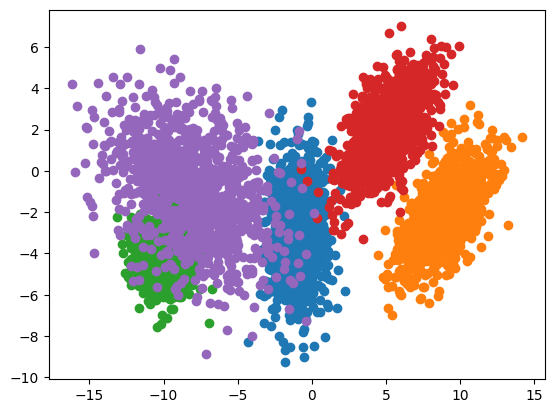

[0.2 0.2 0.2 0.2 0.2]


In [350]:
def main():
  num_components = 5
  mean_matrix, cov_matrix, component_weights_matrix, dataset_log_likelihood_matrix, iterations = EM_uwplatt(generate_dataset(num_components, 1000), num_components)

    # After the EM algorithm finishes, main() will produce a
    # 3D plot of the trained GMM pdf and its final contour plot.
    # It will also plot the dataset log likelihood trend over the training iterations.


if __name__ == "__main__":
    main()